# Initiate Feature Extraction

In [6]:
import numpy as np
import os
import random
import mne
import enum


class BrainMasterMontage(enum.Enum):
    Fp1 = 1
    F3 = 2
    C3 = 3
    P3 = 4
    O1 = 5
    F7 = 6
    T3 = 7
    T5 = 8
    Fz = 9
    Fp2 = 10
    F4 = 11
    C4 = 12
    P4 = 13
    O2 = 14
    F8 = 15
    T4 = 16
    T6 = 17
    Cz = 18
    Pz = 19



# === CHANGE THIS TO SWITCH BETWEEN MODMA AND PREDCT DATASET ===
whichEpochsDir = "/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles/"         # !!!!
whichFeaturesDir = "/Users/wachiii/Workschii/brain-asd/data/data_lancaster/features/"      # !!!!

# --- SET VARIABLES FOR FEATURES EXTRACTION PROCESS -------------
SFREQ = 256                              # !!!!
NUM_CHANNELS = 19
NUM_UNSEEN_HC_SUBJECTS = 5
NUM_UNSEEN_MDD_SUBJECTS = 5
# ===============================================================

mddEpochDir = whichEpochsDir + "/asd"
hcEpochDir = whichEpochsDir + "/hc"

In [52]:
# # List all MDD and HC files
# mddFiles = [os.path.join(mddEpochDir, f) for f in os.listdir(mddEpochDir) if f.endswith(".fif")]
# hcFiles = [os.path.join(hcEpochDir, f) for f in os.listdir(hcEpochDir) if f.endswith(".fif")]

# # Get the total number of subjects
# totalMddSubjects = len(mddFiles)
# totalHcSubjects = len(hcFiles)

# # Randomly select unseen MDD and HC files
# mddUnseenFiles = random.sample(mddFiles, NUM_UNSEEN_MDD_SUBJECTS)
# hcUnseenFiles = random.sample(hcFiles, NUM_UNSEEN_HC_SUBJECTS)

# # print which files are unseen
# print("Unseen MDD files:", mddUnseenFiles)
# print("Unseen HC files:", hcUnseenFiles)

In [ ]:
# List all MDD and HC files
mddFiles = [os.path.join(mddEpochDir, f) for f in os.listdir(mddEpochDir) if f.endswith(".fif")]
hcFiles = [os.path.join(hcEpochDir, f) for f in os.listdir(hcEpochDir) if f.endswith(".fif")]

# Get the total number of subjects
totalMddSubjects = len(mddFiles)
totalHcSubjects = len(hcFiles)

# Randomly select unseen MDD and HC files
mddUnseenFiles = random.sample(mddFiles, NUM_UNSEEN_MDD_SUBJECTS)
hcUnseenFiles = random.sample(hcFiles, NUM_UNSEEN_HC_SUBJECTS)

# print which files are unseen
print("Unseen MDD files:", mddUnseenFiles)
print("Unseen HC files:", hcUnseenFiles)

# Exclude unseen files from the main epoch files
mddEpochFiles = [f for f in mddFiles if f not in mddUnseenFiles]
hcEpochFiles = [f for f in hcFiles if f not in hcUnseenFiles]

# Limit the number of epochs based on the remaining subjects
numMddEpochs = max(0, totalMddSubjects - NUM_UNSEEN_MDD_SUBJECTS)
numHcEpochs = max(0, totalHcSubjects - NUM_UNSEEN_HC_SUBJECTS)
mddEpochFiles = mddEpochFiles[:numMddEpochs]
hcEpochFiles = hcEpochFiles[:numHcEpochs]

# Load and concatenate epochs
mddUnseenEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in mddUnseenFiles])
hcUnseenEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in hcUnseenFiles])
mddEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in mddEpochFiles])
hcEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in hcEpochFiles])

Unseen MDD files: ['/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD1.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD3.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD2.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD4.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD5.fif']
Unseen HC files: ['/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//hc/OrderdSegmentCG5.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//hc/OrderdSegmentCG1.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//hc/OrderdSegmentCG3.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//hc/OrderdSegmentCG2.fif', '/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//hc/Orderd

/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_10685/1122941626.py:28: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD1.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  mddUnseenEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in mddUnseenFiles])
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_10685/1122941626.py:28: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/data/data_lancaster/epoch30sFiles//asd/OrderdSegmentASD3.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  mddUnseenEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in mddUnseenFiles])
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_10685/1122941626.py:28: RuntimeWarning: This filename (/Users/wachiii/Workschii/brain-asd/dat

In [55]:
# mddFiles = [os.path.join(mddEpochDir, f) for f in os.listdir(mddEpochDir) if f.endswith(".fif")]
# hcFiles = [os.path.join(hcEpochDir, f) for f in os.listdir(hcEpochDir) if f.endswith(".fif")]
# totalMddSubjects = len(mddFiles)
# totalHcSubjects = len(hcFiles)
# numMddEpochs = max(0, totalMddSubjects - NUM_UNSEEN_MDD_SUBJECTS)
# numHcEpochs = max(0, totalHcSubjects - NUM_UNSEEN_HC_SUBJECTS)

# mddUnseenFiles = random.sample(mddFiles, NUM_UNSEEN_MDD_SUBJECTS)
# hcUnseenFiles = random.sample(hcFiles, NUM_UNSEEN_HC_SUBJECTS)

# mddEpochFiles = [f for f in mddFiles if f not in mddUnseenFiles][:numMddEpochs]
# hcEpochFiles = [f for f in hcFiles if f not in hcUnseenFiles][:numHcEpochs]

# mddUnseenEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in mddUnseenFiles])
# hcUnseenEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in hcUnseenFiles])
# mddEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in mddEpochFiles])
# hcEpochs = mne.concatenate_epochs([mne.read_epochs(f) for f in hcEpochFiles])

In [56]:
print(f"Total MDD subjects: {totalMddSubjects}")
print(f"Total HC subjects: {totalHcSubjects}")
print(f"Number of unseen MDD subjects: {len(mddUnseenFiles)}")
print(f"Number of unseen HC subjects: {len(hcUnseenFiles)}")
print(f"Number of MDD epochs: {len(mddEpochFiles)}")
print(f"Number of HC epochs: {len(hcEpochFiles)}")

print(f"mddUnseenEpochs shape: {mddUnseenEpochs.get_data().shape}")
print(f"hcUnseenEpochs shape: {hcUnseenEpochs.get_data().shape}")
print(f"mddEpochs shape: {mddEpochs.get_data().shape}")
print(f"hcEpochs shape: {hcEpochs.get_data().shape}")

Total MDD subjects: 94
Total HC subjects: 94
Number of unseen MDD subjects: 19
Number of unseen HC subjects: 19
Number of MDD epochs: 75
Number of HC epochs: 75
mddUnseenEpochs shape: (342, 20, 7680)
hcUnseenEpochs shape: (342, 20, 7680)
mddEpochs shape: (1350, 20, 7680)
hcEpochs shape: (1350, 20, 7680)


## Feature Extraction

### 1. Band Power

In [ ]:
from brainasd.features.psd import EEGPowerSpectrum

# NOTE: featureDict looks like this:
featureDict = {
    "band_power": {
        "mdd": {
            "delta": [],
            "theta": [],
            "alpha": [],
            "beta": [],
            "gamma": []
            },
        "control": {
            "delta": [],
            "theta": [],
            "alpha": [],
            "beta": [],
            "gamma": []
            }
        }
    }

resultFileEpochMap = [
    ("bandpower_ASD.npy", mddEpochs.get_data()),
    ("bandpower_HC.npy", hcEpochs.get_data()),
    ("bandpower_ASD_unseen.npy", mddUnseenEpochs.get_data()),
    ("bandpower_HC_unseen.npy", hcUnseenEpochs.get_data())
]

bandPowerFeatureDir = whichFeaturesDir + "/bandpower"
if not os.path.exists(bandPowerFeatureDir):
    os.makedirs(bandPowerFeatureDir)    

In [76]:
def calculate_and_save_bandpower_features(result_file_epoch_map, bandpower_feature_dir, sfreq):
    for filename, epochs in result_file_epoch_map:        
        psdObj = EEGPowerSpectrum(epochs, sfreq, ifNormalize=False)
        bandpowerFeatures = psdObj.run()
        save_path = os.path.join(bandpower_feature_dir, filename)
        np.save(save_path, bandpowerFeatures)
        print(f"Saved {filename} to {save_path}")
    print("Feature extraction and saving completed.")

In [77]:
calculate_and_save_bandpower_features(resultFileEpochMap, bandPowerFeatureDir, SFREQ)

Saved bandpower_ASD_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//bandpower/bandpower_ASD_unseen.npy
Saved bandpower_HC_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//bandpower/bandpower_HC_unseen.npy
Feature extraction and saving completed.


### 2. Relative Power

In [ ]:
from brainasd.features.psd import EEGPowerSpectrum


# NOTE: featureDict looks like this:
featureDict = {
    "relative_power": {
        "mdd": {
            "delta": [],
            "theta": [],
            "alpha": [],
            "beta": [],
            "gamma": []
            },
        "control": {
            "delta": [],
            "theta": [],
            "alpha": [],
            "beta": [],
            "gamma": []
            }
        }
    }

resultFileEpochMap = [
    ("relativepower_ASD.npy", mddEpochs.get_data()),
    ("relativepower_HC.npy", hcEpochs.get_data()),
    ("relativepower_ASD_unseen.npy", mddUnseenEpochs.get_data()),
    ("relativepower_HC_unseen.npy", hcUnseenEpochs.get_data())
]

relativePowerFeatureDir = whichFeaturesDir + "/relativepower"
if not os.path.exists(relativePowerFeatureDir):
    os.makedirs(relativePowerFeatureDir)

In [79]:
def calculate_and_save_relative_power_features(result_file_epoch_map, relative_power_feature_dir, sfreq):
    for filename, epochs in result_file_epoch_map:
        psdObj = EEGPowerSpectrum(epochs, sfreq, ifNormalize=True)  
        relativePowerFeatures = psdObj.run()
        save_path = os.path.join(relative_power_feature_dir, filename)
        np.save(save_path, relativePowerFeatures)
        print(f"Saved {filename} to {save_path}")
    print("Relative power feature extraction and saving completed.")

In [80]:
calculate_and_save_relative_power_features(resultFileEpochMap, relativePowerFeatureDir, SFREQ)

Saved relativepower_ASD_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//relativepower/relativepower_ASD_unseen.npy
Saved relativepower_HC_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//relativepower/relativepower_HC_unseen.npy
Relative power feature extraction and saving completed.


### 3. Higuchi Fractral Dimension (HFD)

In [ ]:
from brainasd.features.hfd import EEGHiguchiFractalDimension

# NOTE: featureDict looks like this:
featureDict = {
    "HFD": {
        "mdd": [],
        "control": []
    }
}

resultFileEpochMap = [
    ("hfd_ASD.npy", mddEpochs.get_data()),
    ("hfd_HC.npy", hcEpochs.get_data()),
    ("hfd_ASD_unseen.npy", mddUnseenEpochs.get_data()),
    ("hfd_HC_unseen.npy", hcUnseenEpochs.get_data())
]

hfdFeatureDir = whichFeaturesDir + "/hfd"
if not os.path.exists(hfdFeatureDir):
    os.makedirs(hfdFeatureDir)

In [82]:
def calculate_and_save_hfd_features(result_file_epoch_map, hfd_feature_dir):
    for filename, epochs in result_file_epoch_map: 
        hfdObj = EEGHiguchiFractalDimension(epochs)
        hfdFeatures = hfdObj.run()
        save_path = os.path.join(hfd_feature_dir, filename)
        np.save(save_path, hfdFeatures)
        print(f"Saved {filename} to {save_path}")
    print("HFD feature extraction and saving completed.")

In [83]:
calculate_and_save_hfd_features(resultFileEpochMap, hfdFeatureDir)

Saved hfd_ASD_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//hfd/hfd_ASD_unseen.npy
Saved hfd_HC_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//hfd/hfd_HC_unseen.npy
HFD feature extraction and saving completed.


### 4. Coherences

In [ ]:
from brainasd.features.coherence import EEGCoherence

# NOTE: featureDict looks like this:
featureDict = {
    "coherence": {
        "mdd": {
            "delta": [],
            "theta": [],
            "alpha": [],
            "beta": [],
            "gamma": []
            },
        "control": {
            "delta": [],
            "theta": [],
            "alpha": [],
            "beta": [],
            "gamma": []
            }
        }
    } 

resultFileEpochMap = [
    ("coherence_ASD.npy", mddEpochs.get_data()),
    ("coherence_HC.npy", hcEpochs.get_data()),
    ("coherence_ASD_unseen.npy", mddUnseenEpochs.get_data()),
    ("coherence_HC_unseen.npy", hcUnseenEpochs.get_data())
]

coherenceFeatureDir = whichFeaturesDir + "/coherence"
if not os.path.exists(coherenceFeatureDir):
    os.makedirs(coherenceFeatureDir)

In [85]:
def calculate_and_save_coherence_features(result_file_epoch_map, coherence_feature_dir, sfreq):
    for filename, epoch_data in result_file_epoch_map:
        coherenceObj = EEGCoherence(epoch_data, sfreq)
        coherenceFeatures = coherenceObj.run()
        save_path = os.path.join(coherence_feature_dir, filename)
        np.save(save_path, coherenceFeatures)
        print(f"Saved {filename} to {save_path}")
    print("Coherence feature extraction and saving completed.")

In [86]:
calculate_and_save_coherence_features(resultFileEpochMap, coherenceFeatureDir, SFREQ)

Saved coherence_ASD_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//coherence/coherence_ASD_unseen.npy
Saved coherence_HC_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//coherence/coherence_HC_unseen.npy
Coherence feature extraction and saving completed.


### 5. Correlation Dimension (CD)

In [16]:
from brainasd.features.correlationdimension import EEGCorrelationDimension

# NOTE: featureDict looks like this:
featureDict = {
    "CD": {
        "mdd": [],
        "control": []
    }
}

resultFileEpochMap = [
    ("cd_MDD.npy", mddEpochs.get_data()),
    ("cd_HC.npy", hcEpochs.get_data()),
    ("cd_MDD_unseen.npy", mddUnseenEpochs.get_data()),
    ("cd_HC_unseen.npy", hcUnseenEpochs.get_data())
]

cdFeatureDir = whichFeaturesDir + "/cd"
if not os.path.exists(cdFeatureDir):
    os.makedirs(cdFeatureDir)

In [12]:
def calculate_and_save_cd_features(result_file_epoch_map, cd_feature_dir, sfreq):
    for filename, epoch_data in result_file_epoch_map:
        cdObj = EEGCorrelationDimension(epoch_data, sfreq)
        cdFeatures = cdObj.run()
        save_path = os.path.join(cd_feature_dir, filename)
        np.save(save_path, cdFeatures)
        print(f"Saved {filename} to {save_path}")
    print("Coherence Density feature extraction and saving completed.")

In [13]:
calculate_and_save_cd_features(resultFileEpochMap, cdFeatureDir, SFREQ)

Saved cd_MDD.npy to /Users/wachiii/Workschii/brain-mdd/data/features/modma/cd/cd_MDD.npy
Saved cd_HC.npy to /Users/wachiii/Workschii/brain-mdd/data/features/modma/cd/cd_HC.npy
Saved cd_unseen_MDD.npy to /Users/wachiii/Workschii/brain-mdd/data/features/modma/cd/cd_unseen_MDD.npy
Saved cd_unseen_HC.npy to /Users/wachiii/Workschii/brain-mdd/data/features/modma/cd/cd_unseen_HC.npy
Coherence Density feature extraction and saving completed.


### 6. Sub-band Abs power

In [ ]:
from brainasd.features.psd_subband import EEGSubPowerSpectrum

# NOTE: featureDict looks like this:
featureDict = {
    "sub_band_power": {
        "mdd": {
            "alpha1": [],
            "alpha2": [],
            "beta1": [],
            "beta2": [],
            "beta3": []
            },
        "control": {
            "alpha1": [],
            "alpha2": [],
            "beta1": [],
            "beta2": [],
            "beta3": []
            }
        }
    }

resultFileEpochMap = [
    ("subbandpower_ASD.npy", mddEpochs.get_data()),
    ("subbandpower_HC.npy", hcEpochs.get_data()),
    ("subbandpower_ASD_unseen.npy", mddUnseenEpochs.get_data()),
    ("subbandpower_HC_unseen.npy", hcUnseenEpochs.get_data())
]

subBandPowerFeatureDir = whichFeaturesDir + "/subbandpower"
if not os.path.exists(subBandPowerFeatureDir):
    os.makedirs(subBandPowerFeatureDir)

In [88]:
def calculate_and_save_subband_power_features(result_file_epoch_map, subband_power_feature_dir, sfreq):
    for filename, epochs in result_file_epoch_map:
        psdObj = EEGSubPowerSpectrum(epochs, sfreq, ifNormalize=True)  
        subbandPowerFeatures = psdObj.run()
        save_path = os.path.join(subband_power_feature_dir, filename)
        np.save(save_path, subbandPowerFeatures)
        print(f"Saved {filename} to {save_path}")
    print("Sub-band power feature extraction and saving completed.")

In [89]:
calculate_and_save_subband_power_features(resultFileEpochMap, subBandPowerFeatureDir, SFREQ)

Saved subbandpower_ASD_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//subbandpower/subbandpower_ASD_unseen.npy
Saved subbandpower_HC_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_lancaster/features//subbandpower/subbandpower_HC_unseen.npy
Sub-band power feature extraction and saving completed.


### 7. Alpha-Beta ratio

In [21]:
from brainasd.features.psd import EEGPowerSpectrum

resultFileEpochMap = [
    ("alphabeta_ASD.npy", mddEpochs.get_data()),
    ("alphabeta_HC.npy", hcEpochs.get_data()),
    ("alphabeta_ASD_unseen.npy", mddUnseenEpochs.get_data()),
    ("alphabeta_HC_unseen.npy", hcUnseenEpochs.get_data())
]

bandPowerFeatureDir = whichFeaturesDir + "/alphabeta"
if not os.path.exists(bandPowerFeatureDir):
    os.makedirs(bandPowerFeatureDir)    

In [26]:
def calculate_and_save_alphabeta_ratio_features(result_file_epoch_map, alphabeta_feature_dir, sfreq):
    for filename, epochs in result_file_epoch_map:        
        psdObj = EEGPowerSpectrum(epochs, sfreq, ifNormalize=False)
        bandpowerFeatures = psdObj.run()
        alphabetaFeatures = (bandpowerFeatures[:, 2, :] / bandpowerFeatures[:, 3, :]).reshape(-1, 1, 20)
        save_path = os.path.join(alphabeta_feature_dir, filename)
        np.save(save_path, alphabetaFeatures)
        print(f"shape of {filename}: {alphabetaFeatures.shape}")
        print(f"Saved {filename} to {save_path}")
        

In [27]:
calculate_and_save_alphabeta_ratio_features(resultFileEpochMap, bandPowerFeatureDir, SFREQ)

shape of alphabeta_ASD.npy: (522, 1, 20)
Saved alphabeta_ASD.npy to /Users/wachiii/Workschii/brain-asd/data/data_children/features/30s_epochbasedNew/alphabeta/alphabeta_ASD.npy
shape of alphabeta_HC.npy: (522, 1, 20)
Saved alphabeta_HC.npy to /Users/wachiii/Workschii/brain-asd/data/data_children/features/30s_epochbasedNew/alphabeta/alphabeta_HC.npy
shape of alphabeta_ASD_unseen.npy: (90, 1, 20)
Saved alphabeta_ASD_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_children/features/30s_epochbasedNew/alphabeta/alphabeta_ASD_unseen.npy
shape of alphabeta_HC_unseen.npy: (90, 1, 20)
Saved alphabeta_HC_unseen.npy to /Users/wachiii/Workschii/brain-asd/data/data_children/features/30s_epochbasedNew/alphabeta/alphabeta_HC_unseen.npy


### Alpha-Theta ratio

In [64]:
from brainmdd.features.psd import EEGPowerSpectrum

resultFileEpochMap = [
    ("alphatheta_MDD.npy", mddEpochs.get_data()),
    ("alphatheta_HC.npy", hcEpochs.get_data()),
    ("alphatheta_MDD_unseen.npy", mddUnseenEpochs.get_data()),
    ("alphatheta_HC_unseen.npy", hcUnseenEpochs.get_data())
]

bandPowerFeatureDir = whichFeaturesDir + "/alphatheta"
if not os.path.exists(bandPowerFeatureDir):
    os.makedirs(bandPowerFeatureDir)    

In [65]:
def calculate_and_save_alphatheta_ratio_features(result_file_epoch_map, alphatheta_feature_dir, sfreq):
    for filename, epochs in result_file_epoch_map:        
        psdObj = EEGPowerSpectrum(epochs, sfreq, ifNormalize=False)
        bandpowerFeatures = psdObj.run()
        alphabetaFeatures = (bandpowerFeatures[:, 2, :] / bandpowerFeatures[:, 0, :]).reshape(-1, 1, 16)
        save_path = os.path.join(alphatheta_feature_dir, filename)
        np.save(save_path, alphabetaFeatures)
        print(f"shape of {filename}: {alphabetaFeatures.shape}")

In [66]:
calculate_and_save_alphatheta_ratio_features(resultFileEpochMap, bandPowerFeatureDir, SFREQ)

shape of alphatheta_MDD.npy: (450, 1, 16)
shape of alphatheta_HC.npy: (641, 1, 16)
shape of alphatheta_MDD_unseen.npy: (79, 1, 16)
shape of alphatheta_HC_unseen.npy: (90, 1, 16)


## Inspect Feature

In [44]:
from sklearn.datasets import make_blobs
import dotenv
import os
import random
import mne
import enum
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


class PredCtChannelMapping(enum.Enum):
    Fp1 = 1
    Fp2 = 3
    F3 = 8
    F4 = 12
    C3 = 26
    C4 = 30
    P3 = 46
    P4 = 50
    O1 = 61
    O2 = 63
    F7 = 6
    F8 = 14
    T7 = 24 ## was T3
    T8 = 32 ## was T4
    P7 = 44 ## was T5
    P8 = 52 ## was T6

class ModmaChannelMapping(enum.Enum):
    Fp1 = 22
    Fp2 = 9
    F3 = 24
    F4 = 124
    C3 = 36
    C4 = 104
    P3 = 52
    P4 = 92
    O1 = 70
    O2 = 83
    F7 = 33
    F8 = 122
    T3 = 45
    T4 = 108
    T5 = 58
    T6 = 96
    
    
modmaFeaturesDir = os.getenv("MODMA_30S_FEATURES_DIR")
predctFeaturesDir = os.getenv("PREDCT_30S_FEATURES_DIR")

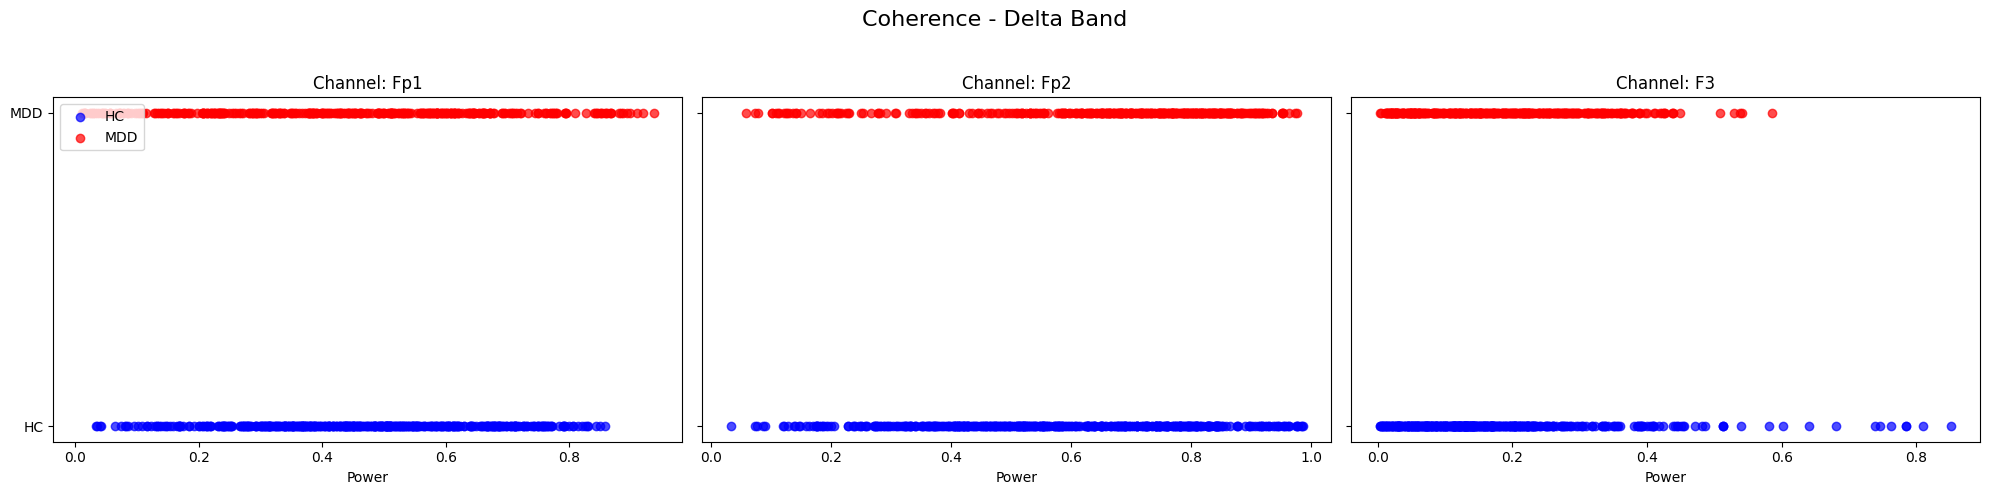

In [61]:
whichFeatureToPlot = "coherence" # !!!!
whichDatasetToPlot = modmaFeaturesDir # !!!!
whichChannel = 3

hcDataToplotPath = modmaFeaturesDir + "/" + whichFeatureToPlot + "/" + f"{whichFeatureToPlot}_HC.npy"
mddDataToplotPath = modmaFeaturesDir + "/" + whichFeatureToPlot + "/" + f"{whichFeatureToPlot}_MDD.npy"

# Load the data
hcFeatures = np.load(hcDataToplotPath)
mddFeatures = np.load(mddDataToplotPath)

# Frequency bands
freqBands = ["Delta", "Theta", "Alpha", "Beta", "Gamma"]

# Channels to plot (indices correspond to Fp1 = 0, Fp2 = 1, etc.)
channelsToPlot = {
    "Fp1": 0,
    "Fp2": 1,
    "F3": 2
}

# Frequency band to pick (e.g., Delta = index 0, Theta = index 1, etc.)
freqBandIndex = 0  # Change this to select a different frequency band (0 = Delta, 1 = Theta, etc.)

# Create subplots
fig, axes = plt.subplots(1, len(channelsToPlot), figsize=(20, 5), sharey=True)
fig.suptitle(f"{whichFeatureToPlot.capitalize()} - {freqBands[freqBandIndex]} Band", fontsize=16)

# Loop through channels and plot
for i, (channelName, channelIndex) in enumerate(channelsToPlot.items()):
    # Extract data for the specific frequency band and channel
    hcData = hcFeatures[:, freqBandIndex, channelIndex]
    mddData = mddFeatures[:, freqBandIndex, channelIndex]

    # Plot HC and MDD data
    ax = axes[i]
    ax.scatter(hcData, np.zeros_like(hcData), label="HC", alpha=0.7, color="blue")
    ax.scatter(mddData, np.ones_like(mddData), label="MDD", alpha=0.7, color="red")
    ax.set_title(f"Channel: {channelName}", fontsize=12)
    ax.set_xlabel("Power")
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["HC", "MDD"])

# Add legend to the first subplot
axes[0].legend(loc="upper left")

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Whole Signal Feature Extraction (No Epoching)
Extract bandpower features from complete subject signals by concatenating overlapping epochs

In [12]:
import numpy as np
import os
import mne
from scipy import signal
from scipy.signal import welch
import matplotlib.pyplot as plt



def concatenate_overlapping_epochs(epochs_data, overlap_ratio=0.5):
    """
    Concatenate overlapping epochs back into continuous signal
    
    Parameters:
    epochs_data: numpy array of shape (n_epochs, n_channels, n_samples)
    overlap_ratio: float, overlap ratio (0.5 for 50% overlap)
    
    Returns:
    continuous_signal: numpy array of shape (n_channels, total_samples)
    """
    n_epochs, n_channels, epoch_length = epochs_data.shape
    
    # Calculate step size based on overlap
    step_size = int(epoch_length * (1 - overlap_ratio))
    
    # Calculate total length of concatenated signal
    total_length = (n_epochs - 1) * step_size + epoch_length
    
    # Initialize output array
    continuous_signal = np.zeros((n_channels, total_length))
    weight_matrix = np.zeros((n_channels, total_length))
    
    # Concatenate epochs with proper overlap handling
    for i in range(n_epochs):
        start_idx = i * step_size
        end_idx = start_idx + epoch_length
        
        # Add epoch data to continuous signal
        continuous_signal[:, start_idx:end_idx] += epochs_data[i]
        weight_matrix[:, start_idx:end_idx] += 1
    
    # Average overlapping regions
    continuous_signal = np.divide(continuous_signal, weight_matrix, 
                                 out=np.zeros_like(continuous_signal), 
                                 where=weight_matrix!=0)
    return continuous_signal


def calculate_bandpower_whole_signal(signal_data, sfreq, bands=None):
    """
    Calculate bandpower for frequency bands from whole signal
    
    Parameters:
    signal_data: numpy array of shape (n_channels, n_samples)
    sfreq: sampling frequency
    bands: dict of frequency bands, default is standard EEG bands
    
    Returns:
    bandpower_features: numpy array of shape (n_bands, n_channels-1) - excludes last channel
    """
    if bands is None:
        bands = {
            'delta': (0.5, 4),
            'theta': (4, 8),
            'alpha': (8, 13),
            'beta': (13, 30),
            'gamma': (30, 45)
        }
    
    # Exclude the last channel (Pz) - use only first 19 channels
    n_channels = signal_data.shape[0] - 1  # 19 channels instead of 20
    n_bands = len(bands)
    bandpower_features = np.zeros((n_bands, n_channels))
    
    for ch in range(n_channels):  # Only process first 19 channels
        # Calculate power spectral density using Welch's method
        freqs, psd = welch(signal_data[ch], sfreq, nperseg=int(sfreq*4))
        
        # Calculate power in each frequency band
        for i, (band_name, (low_freq, high_freq)) in enumerate(bands.items()):
            # Find frequency indices for the band
            freq_mask = (freqs >= low_freq) & (freqs < high_freq)
            
            # Calculate band power (area under PSD curve in the band)
            bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
    
    return bandpower_features

def process_subject_files_for_whole_signal_features(epoch_dir, output_dir, sfreq=256, overlap_ratio=0.5):
    """
    Process all subject files in a directory to extract whole signal bandpower features
    
    Parameters:
    epoch_dir: directory containing .fif epoch files
    output_dir: directory to save bandpower features
    sfreq: sampling frequency
    overlap_ratio: overlap ratio for concatenation (0.5 for 50%)
    """
    # Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Get all .fif files in the directory
    fif_files = [f for f in os.listdir(epoch_dir) if f.endswith('.fif')]
    
    print(f"Found {len(fif_files)} subject files to process")
    
    for fif_file in fif_files:
        try:
            # Load epochs for this subject
            file_path = os.path.join(epoch_dir, fif_file)
            epochs = mne.read_epochs(file_path, preload=True, verbose=False)
            
            # Get epoch data (n_epochs, n_channels, n_samples)
            epochs_data = epochs.get_data()
            
            print(f"Processing {fif_file}: {epochs_data.shape[0]} epochs, "
                  f"{epochs_data.shape[1]} channels, {epochs_data.shape[2]} samples per epoch")
            
            # Concatenate overlapping epochs back to continuous signal
            continuous_signal = concatenate_overlapping_epochs(epochs_data, overlap_ratio)
            
            print(f"Concatenated signal shape: {continuous_signal.shape}")
            print(f"Signal duration: {continuous_signal.shape[1]/sfreq:.2f} seconds")
            
            # Calculate bandpower features from whole signal (now returns 5x19 instead of 5x20)
            bandpower_features = calculate_bandpower_whole_signal(continuous_signal, sfreq)
            
            print(f"Bandpower features shape: {bandpower_features.shape} (5 bands × 19 channels)")
            
            # Create output filename (replace .fif with _bandpower.npy)
            output_filename = fif_file.replace('.fif', '_bandpower.npy')
            output_path = os.path.join(output_dir, output_filename)
            
            # Save features
            np.save(output_path, bandpower_features)
            
            print(f"Saved {output_filename} to {output_path}")
            print("-" * 60)
            
        except Exception as e:
            print(f"Error processing {fif_file}: {str(e)}")
            continue
    
    print("Whole signal feature extraction completed!")

# Example usage and configuration
whichEpochsDir_WholeSignal = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles"
whichFeaturesDir_WholeSignal = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/"

# Create output directory structure
asd_output_dir = os.path.join(whichFeaturesDir_WholeSignal, "bandpower", "asd")
hc_output_dir = os.path.join(whichFeaturesDir_WholeSignal, "bandpower", "hc")

# Set paths for ASD and HC epoch directories
asd_epoch_dir = os.path.join(whichEpochsDir_WholeSignal, "asd")
hc_epoch_dir = os.path.join(whichEpochsDir_WholeSignal, "hc")

In [13]:
# Process ASD subjects
print("=" * 80)
print("PROCESSING ASD SUBJECTS")
print("=" * 80)
process_subject_files_for_whole_signal_features(
    epoch_dir=asd_epoch_dir, 
    output_dir=asd_output_dir, 
    sfreq=SFREQ, 
    overlap_ratio=0.5
)

# Process HC subjects
print("\n" + "=" * 80)
print("PROCESSING HC (CONTROL) SUBJECTS") 
print("=" * 80)
process_subject_files_for_whole_signal_features(
    epoch_dir=hc_epoch_dir, 
    output_dir=hc_output_dir, 
    sfreq=SFREQ, 
    overlap_ratio=0.5
)

PROCESSING ASD SUBJECTS
Found 35 subject files to process
Processing A28_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Signal duration: 105.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A28_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A28_EC_bandpower.npy
------------------------------------------------------------
Processing A24_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Signal duration: 105.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A24_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A24_EC_bandpower.npy
------------------------------------------------------------
Processing A12_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Sign

/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:112: RuntimeWarning: This filename (/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles/asd/A28_EC.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path, preload=True, verbose=False)
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:112: RuntimeWarning: This filename (/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles/asd/A24_EC.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -e

Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A30_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A30_EC_bandpower.npy
------------------------------------------------------------
Processing A22_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Signal duration: 105.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A22_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A22_EC_bandpower.npy
------------------------------------------------------------
Processing A04_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Signal duration: 105.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A04_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whol

/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:112: RuntimeWarning: This filename (/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles/asd/A27_EC.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path, preload=True, verbose=False)
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folder

Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A11_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A11_EC_bandpower.npy
------------------------------------------------------------
Processing A27_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Signal duration: 105.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A27_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A27_EC_bandpower.npy
------------------------------------------------------------
Processing A35_EC.fif: 6 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 26880)
Signal duration: 105.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved A35_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whol

/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:112: RuntimeWarning: This filename (/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles/hc/H11_EC.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path, preload=True, verbose=False)
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folders

Saved A09_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd/A09_EC_bandpower.npy
------------------------------------------------------------
Whole signal feature extraction completed!

PROCESSING HC (CONTROL) SUBJECTS
Found 17 subject files to process
Processing H11_EC.fif: 2 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 11520)
Signal duration: 45.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved H11_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/hc/H11_EC_bandpower.npy
------------------------------------------------------------
Processing H03_EC.fif: 10 epochs, 20 channels, 7680 samples per epoch
Concatenated signal shape: (20, 42240)
Signal duration: 165.00 seconds
Bandpower features shape: (5, 19) (5 bands × 19 channels)
Saved H03_EC_bandpower.npy to /Users/wachiii/Workschii/BCI/A

/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:112: RuntimeWarning: This filename (/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles/hc/H06_EC.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path, preload=True, verbose=False)
/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_62345/3379608046.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  bandpower_features[i, ch] = np.trapz(psd[freq_mask], freqs[freq_mask])
/var/folders

In [14]:
# Resave existing features with corrected shape (5, 19) - excluding last channel (Pz)
def resave_features_exclude_last_channel(feature_dir, backup_suffix="_backup_5x20"):
    """
    Resave existing bandpower features excluding the last channel (Pz)
    Changes shape from (5, 20) to (5, 19)
    
    Parameters:
    feature_dir: directory containing _bandpower.npy files
    backup_suffix: suffix for backup files
    """
    if not os.path.exists(feature_dir):
        print(f"Directory not found: {feature_dir}")
        return
    
    # Get all bandpower files
    feature_files = [f for f in os.listdir(feature_dir) if f.endswith('_bandpower.npy')]
    
    if not feature_files:
        print(f"No _bandpower.npy files found in {feature_dir}")
        return
    
    print(f"Found {len(feature_files)} files to resave with shape (5, 19)")
    print("-" * 60)
    
    resaved_count = 0
    
    for file_name in feature_files:
        try:
            file_path = os.path.join(feature_dir, file_name)
            
            # Load existing features
            features = np.load(file_path)
            
            print(f"Processing {file_name}: original shape {features.shape}")
            
            # Check if features have the expected shape
            if features.shape == (5, 20):
                # Create backup with original features
                backup_name = file_name.replace('_bandpower.npy', f'{backup_suffix}_bandpower.npy')
                backup_path = os.path.join(feature_dir, backup_name)
                np.save(backup_path, features)
                print(f"  Backup saved as: {backup_name}")
                
                # Remove last channel (Pz) - keep only first 19 channels
                corrected_features = features[:, :19]  # Shape becomes (5, 19)
                
                # Save corrected features
                np.save(file_path, corrected_features)
                
                print(f"  Resaved with shape: {corrected_features.shape}")
                resaved_count += 1
                
            elif features.shape == (5, 19):
                print(f"  Already correct shape: {features.shape}")
                
            else:
                print(f"  Unexpected shape: {features.shape} - skipping")
            
        except Exception as e:
            print(f"  Error processing {file_name}: {str(e)}")
        
        print("-" * 40)
    
    print(f"Completed! Resaved {resaved_count} files with shape (5, 19)")
    print(f"Backup files created with suffix '{backup_suffix}'")

# Resave ASD features
print("=" * 80)
print("RESAVING ASD FEATURES - EXCLUDING LAST CHANNEL (Pz)")
print("=" * 80)
resave_features_exclude_last_channel(asd_output_dir)

print("\n" + "=" * 80) 
print("RESAVING HC FEATURES - EXCLUDING LAST CHANNEL (Pz)")
print("=" * 80)
resave_features_exclude_last_channel(hc_output_dir)

RESAVING ASD FEATURES - EXCLUDING LAST CHANNEL (Pz)
Found 35 files to resave with shape (5, 19)
------------------------------------------------------------
Processing A33_EC_bandpower.npy: original shape (5, 19)
  Already correct shape: (5, 19)
----------------------------------------
Processing A12_EC_bandpower.npy: original shape (5, 19)
  Already correct shape: (5, 19)
----------------------------------------
Processing A06_EC_bandpower.npy: original shape (5, 19)
  Already correct shape: (5, 19)
----------------------------------------
Processing A27_EC_bandpower.npy: original shape (5, 19)
  Already correct shape: (5, 19)
----------------------------------------
Processing A19_EC_bandpower.npy: original shape (5, 19)
  Already correct shape: (5, 19)
----------------------------------------
Processing A23_EC_bandpower.npy: original shape (5, 19)
  Already correct shape: (5, 19)
----------------------------------------
Processing A02_EC_bandpower.npy: original shape (5, 19)
  Alrea

In [15]:
# Verify the extracted features
print("\n" + "=" * 80)
print("VERIFICATION - INSPECTING EXTRACTED FEATURES")
print("=" * 80)

# Check ASD features
asd_files = [f for f in os.listdir(asd_output_dir) if f.endswith('_bandpower.npy')]
hc_files = [f for f in os.listdir(hc_output_dir) if f.endswith('_bandpower.npy')]

print(f"Number of ASD subject files: {len(asd_files)}")
print(f"Number of HC subject files: {len(hc_files)}")

# Load and inspect a sample file
if asd_files:
    sample_asd_file = os.path.join(asd_output_dir, asd_files[0])
    sample_features = np.load(sample_asd_file)
    print(f"\nSample ASD features shape: {sample_features.shape}")
    print(f"Feature dimensions: {sample_features.shape[0]} bands × {sample_features.shape[1]} channels")
    
    # Show frequency bands and their indices
    bands = ['Delta (0.5-4Hz)', 'Theta (4-8Hz)', 'Alpha (8-13Hz)', 'Beta (13-30Hz)', 'Gamma (30-45Hz)']
    print("\nFrequency bands:")
    for i, band in enumerate(bands):
        print(f"  Band {i}: {band}")
    
    # Show sample values for first subject, first few channels
    print(f"\nSample bandpower values for {asd_files[0]}:")
    print("Channels: Fp1, F3, C3, P3, O1")
    for i, band in enumerate(bands):
        band_values = sample_features[i, :5]  # First 5 channels
        print(f"{band}: {band_values}")

if hc_files:
    sample_hc_file = os.path.join(hc_output_dir, hc_files[0])
    sample_features_hc = np.load(sample_hc_file)
    print(f"\nSample HC features shape: {sample_features_hc.shape}")

print(f"\nFeatures saved in:")
print(f"  ASD: {asd_output_dir}")
print(f"  HC:  {hc_output_dir}")


VERIFICATION - INSPECTING EXTRACTED FEATURES
Number of ASD subject files: 35
Number of HC subject files: 17

Sample ASD features shape: (5, 19)
Feature dimensions: 5 bands × 19 channels

Frequency bands:
  Band 0: Delta (0.5-4Hz)
  Band 1: Theta (4-8Hz)
  Band 2: Alpha (8-13Hz)
  Band 3: Beta (13-30Hz)
  Band 4: Gamma (30-45Hz)

Sample bandpower values for A33_EC_bandpower.npy:
Channels: Fp1, F3, C3, P3, O1
Delta (0.5-4Hz): [1295.45745652 1182.79565597  646.37404487  628.2840571   660.17120693]
Theta (4-8Hz): [918.44928162 539.96008837 352.71631943 347.38148174 334.52231734]
Alpha (8-13Hz): [580.67509751 366.29740932 151.38881909 171.1943555  202.50030498]
Beta (13-30Hz): [298.91890861 404.90890634 148.23828495 101.2538828   99.11043082]
Gamma (30-45Hz): [25.46003249 24.57410906  9.05902475  4.47492187  4.0846399 ]

Sample HC features shape: (5, 19)

Features saved in:
  ASD: /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/features/whole_signal/bandpower/asd
  HC:


OPTIONAL VISUALIZATION


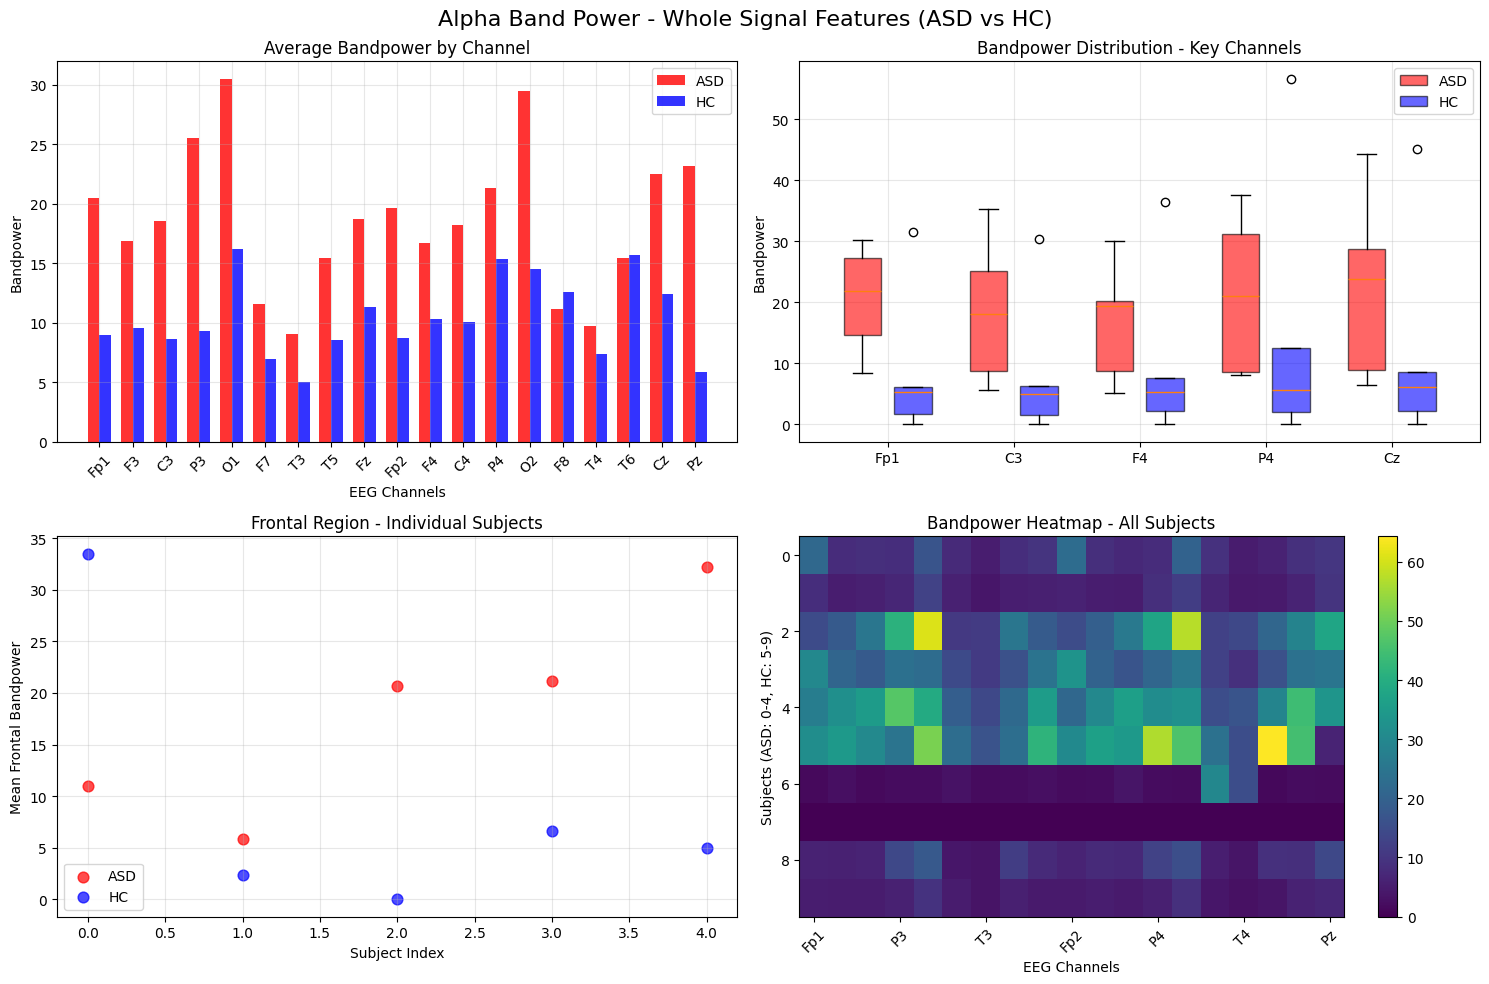

Visualization function defined. Uncomment the last line to run.


In [2]:
# Optional: Visualize the extracted features
print("\n" + "=" * 80)
print("OPTIONAL VISUALIZATION")
print("=" * 80)

def plot_bandpower_comparison(asd_dir, hc_dir, n_subjects=5, band_idx=2):
    """
    Plot bandpower comparison between ASD and HC subjects
    
    Parameters:
    asd_dir, hc_dir: directories containing subject features
    n_subjects: number of subjects to plot from each group
    band_idx: frequency band index to plot (2 = Alpha band)
    """
    bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
    channels = ['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 
                'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz', 'Pz']
    
    # Load ASD and HC features
    asd_files = [f for f in os.listdir(asd_dir) if f.endswith('_bandpower.npy')][:n_subjects]
    hc_files = [f for f in os.listdir(hc_dir) if f.endswith('_bandpower.npy')][:n_subjects]
    
    asd_features = []
    hc_features = []
    
    for file in asd_files:
        features = np.load(os.path.join(asd_dir, file))
        asd_features.append(features[band_idx, :])  # Extract specific band
    
    for file in hc_files:
        features = np.load(os.path.join(hc_dir, file))
        hc_features.append(features[band_idx, :])   # Extract specific band
    
    asd_features = np.array(asd_features)
    hc_features = np.array(hc_features)
    
    # Create plot
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'{bands[band_idx]} Band Power - Whole Signal Features (ASD vs HC)', fontsize=16)
    
    # Plot 1: Average bandpower across channels
    ax1 = axes[0, 0]
    asd_mean = np.mean(asd_features, axis=0)
    hc_mean = np.mean(hc_features, axis=0)
    
    x = np.arange(len(channels))
    width = 0.35
    
    ax1.bar(x - width/2, asd_mean, width, label='ASD', alpha=0.8, color='red')
    ax1.bar(x + width/2, hc_mean, width, label='HC', alpha=0.8, color='blue')
    ax1.set_xlabel('EEG Channels')
    ax1.set_ylabel('Bandpower')
    ax1.set_title('Average Bandpower by Channel')
    ax1.set_xticks(x)
    ax1.set_xticklabels(channels, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Box plot for specific channels
    ax2 = axes[0, 1]
    key_channels = [0, 2, 10, 12, 17]  # Fp1, C3, F4, P4, Cz
    key_channel_names = [channels[i] for i in key_channels]
    
    asd_key = asd_features[:, key_channels]
    hc_key = hc_features[:, key_channels]
    
    positions = np.arange(len(key_channels))
    bp1 = ax2.boxplot([asd_key[:, i] for i in range(len(key_channels))], 
                      positions=positions - 0.2, widths=0.3, patch_artist=True)
    bp2 = ax2.boxplot([hc_key[:, i] for i in range(len(key_channels))], 
                      positions=positions + 0.2, widths=0.3, patch_artist=True)
    
    for patch in bp1['boxes']:
        patch.set_facecolor('red')
        patch.set_alpha(0.6)
    for patch in bp2['boxes']:
        patch.set_facecolor('blue')
        patch.set_alpha(0.6)
    
    ax2.set_xticks(positions)
    ax2.set_xticklabels(key_channel_names)
    ax2.set_ylabel('Bandpower')
    ax2.set_title('Bandpower Distribution - Key Channels')
    ax2.legend([bp1["boxes"][0], bp2["boxes"][0]], ['ASD', 'HC'])
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Subject-wise comparison (frontal region)
    ax3 = axes[1, 0]
    frontal_channels = [0, 1, 2, 10, 11]  # Fp1, Fp2, F3, F4, Fz
    asd_frontal = np.mean(asd_features[:, frontal_channels], axis=1)
    hc_frontal = np.mean(hc_features[:, frontal_channels], axis=1)
    
    ax3.scatter(range(len(asd_frontal)), asd_frontal, color='red', alpha=0.7, label='ASD', s=60)
    ax3.scatter(range(len(hc_frontal)), hc_frontal, color='blue', alpha=0.7, label='HC', s=60)
    ax3.set_xlabel('Subject Index')
    ax3.set_ylabel('Mean Frontal Bandpower')
    ax3.set_title('Frontal Region - Individual Subjects')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: All subjects heatmap
    ax4 = axes[1, 1]
    all_features = np.vstack([asd_features, hc_features])
    im = ax4.imshow(all_features, aspect='auto', cmap='viridis')
    ax4.set_xlabel('EEG Channels')
    ax4.set_ylabel('Subjects (ASD: 0-{}, HC: {}-{})'.format(len(asd_features)-1, 
                                                            len(asd_features), 
                                                            len(asd_features)+len(hc_features)-1))
    ax4.set_title('Bandpower Heatmap - All Subjects')
    ax4.set_xticks(range(0, len(channels), 3))
    ax4.set_xticklabels([channels[i] for i in range(0, len(channels), 3)], rotation=45)
    
    plt.colorbar(im, ax=ax4)
    plt.tight_layout()
    plt.show()
    
    return asd_features, hc_features
asd_features_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/asd"
hc_features_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/hc"    
# Run visualization (uncomment to execute)
asd_features, hc_features = plot_bandpower_comparison(asd_features_dir, hc_features_dir,  
                                                     n_subjects=5, band_idx=2)
print("Visualization function defined. Uncomment the last line to run.")

WHOLE SIGNAL BANDPOWER FEATURES ANALYSIS (19 channels)
Found 35 ASD subject files
Found 17 HC subject files

Loading ASD features...
  A03_EC_raw_bandpower.npy: shape (5, 19)
  A06_EC_raw_bandpower.npy: shape (5, 19)
  A31_EC_raw_bandpower.npy: shape (5, 19)
  A09_EC_raw_bandpower.npy: shape (5, 19)
  A34_EC_raw_bandpower.npy: shape (5, 19)
  A26_EC_raw_bandpower.npy: shape (5, 19)
  A23_EC_raw_bandpower.npy: shape (5, 19)
  A14_EC_raw_bandpower.npy: shape (5, 19)
  A11_EC_raw_bandpower.npy: shape (5, 19)
  A29_EC_raw_bandpower.npy: shape (5, 19)
  A08_EC_raw_bandpower.npy: shape (5, 19)
  A30_EC_raw_bandpower.npy: shape (5, 19)
  A35_EC_raw_bandpower.npy: shape (5, 19)
  A02_EC_raw_bandpower.npy: shape (5, 19)
  A07_EC_raw_bandpower.npy: shape (5, 19)
  A15_EC_raw_bandpower.npy: shape (5, 19)
  A28_EC_raw_bandpower.npy: shape (5, 19)
  A10_EC_raw_bandpower.npy: shape (5, 19)
  A27_EC_raw_bandpower.npy: shape (5, 19)
  A22_EC_raw_bandpower.npy: shape (5, 19)
  A19_EC_raw_bandpower.npy:

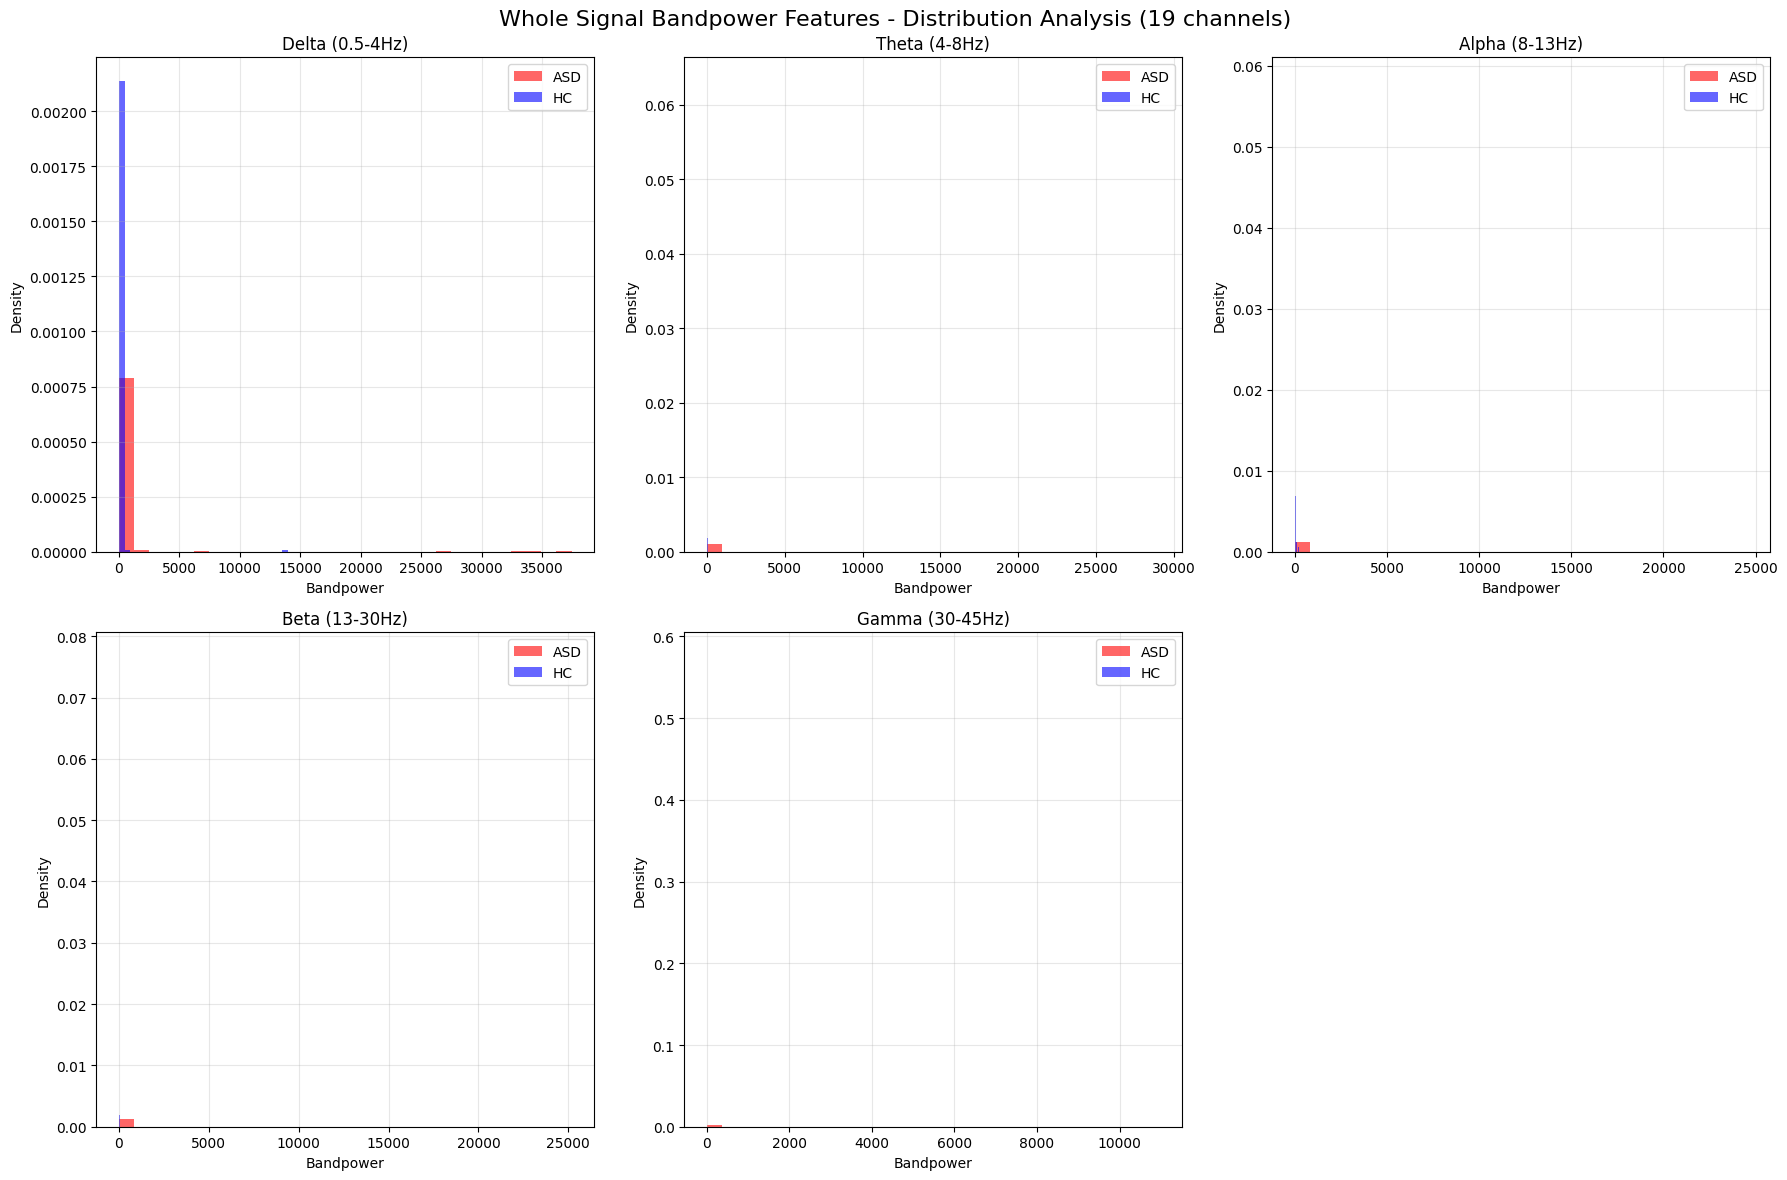

/var/folders/kf/plh_bl0s64g1swyqvnc651pr0000gn/T/ipykernel_1739/2116475001.py:225: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = ax.boxplot(plot_data, labels=labels, patch_artist=True)


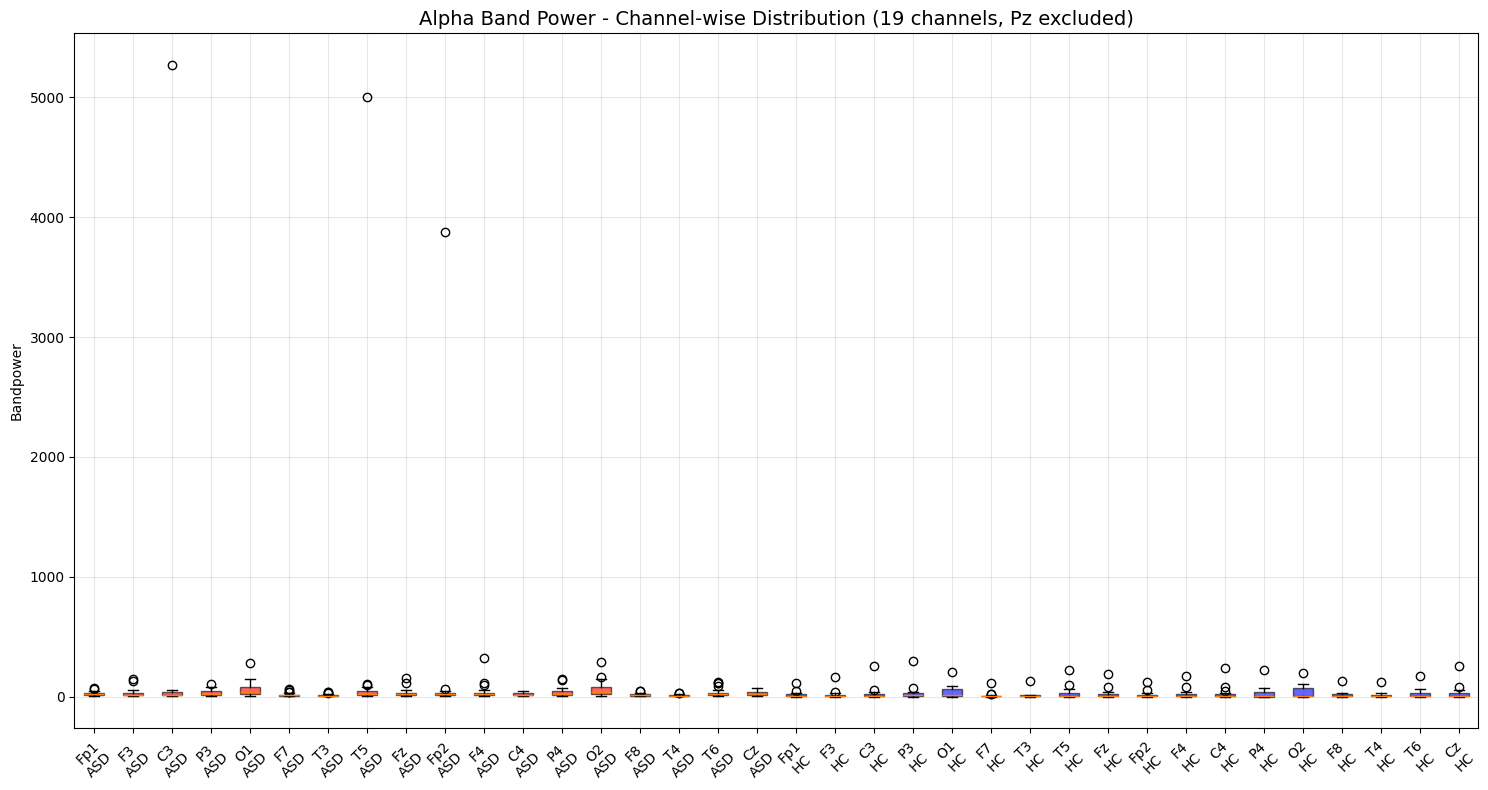

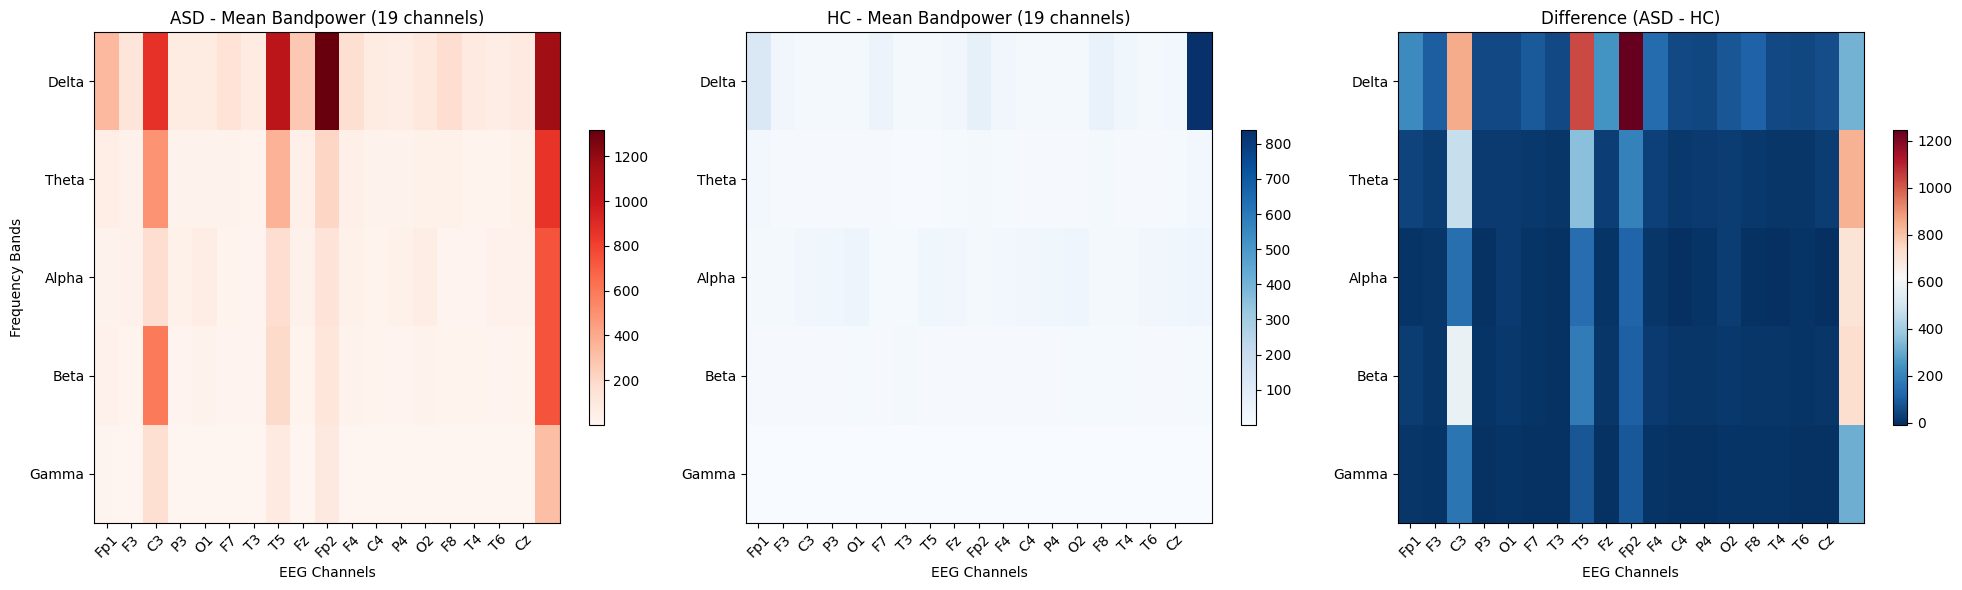

Analysis completed!


In [1]:
# Recheck and analyze whole signal bandpower features
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
import seaborn as sns

# Define paths for analysis
asd_feature_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/asd"
hc_feature_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/hc"

def analyze_whole_signal_features(asd_dir, hc_dir):
    """
    Comprehensive analysis of whole signal bandpower features
    """
    print("=" * 80)
    print("WHOLE SIGNAL BANDPOWER FEATURES ANALYSIS (19 channels)")
    print("=" * 80)
    
    # Check if directories exist
    if not os.path.exists(asd_dir):
        print(f"ASD directory not found: {asd_dir}")
        return
    if not os.path.exists(hc_dir):
        print(f"HC directory not found: {hc_dir}")
        return
    
    # Get all feature files
    asd_files = [f for f in os.listdir(asd_dir) if f.endswith('_bandpower.npy')]
    hc_files = [f for f in os.listdir(hc_dir) if f.endswith('_bandpower.npy')]
    
    print(f"Found {len(asd_files)} ASD subject files")
    print(f"Found {len(hc_files)} HC subject files")
    
    if len(asd_files) == 0 and len(hc_files) == 0:
        print("No feature files found in the directories!")
        return
    
    # Load all features
    asd_features = []
    hc_features = []
    
    # Load ASD features
    print("\nLoading ASD features...")
    for i, file in enumerate(asd_files):
        try:
            features = np.load(os.path.join(asd_dir, file))
            print(f"  {file}: shape {features.shape}")
            asd_features.append(features)
        except Exception as e:
            print(f"  Error loading {file}: {e}")
    
    # Load HC features
    print("\nLoading HC features...")
    for i, file in enumerate(hc_files):
        try:
            features = np.load(os.path.join(hc_dir, file))
            print(f"  {file}: shape {features.shape}")
            hc_features.append(features)
        except Exception as e:
            print(f"  Error loading {file}: {e}")
    
    if not asd_features and not hc_features:
        print("No valid feature files could be loaded!")
        return
    
    # Convert to arrays if we have data
    if asd_features:
        asd_features = np.array(asd_features)  # Shape: (n_subjects, n_bands, n_channels)
        print(f"\nASD features array shape: {asd_features.shape}")
        print(f"  {asd_features.shape[0]} subjects")
        print(f"  {asd_features.shape[1]} frequency bands")
        print(f"  {asd_features.shape[2]} EEG channels (excluding Pz)")
    
    if hc_features:
        hc_features = np.array(hc_features)   # Shape: (n_subjects, n_bands, n_channels)
        print(f"\nHC features array shape: {hc_features.shape}")
        print(f"  {hc_features.shape[0]} subjects")
        print(f"  {hc_features.shape[1]} frequency bands")
        print(f"  {hc_features.shape[2]} EEG channels (excluding Pz)")
    
    # Define band and channel names (19 channels - excluding Pz)
    bands = ['Delta (0.5-4Hz)', 'Theta (4-8Hz)', 'Alpha (8-13Hz)', 'Beta (13-30Hz)', 'Gamma (30-45Hz)']
    channels = ['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 
                'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz']  # Removed 'Pz'
    
    print(f"\nUsing {len(channels)} channels: {channels}")
    
    # Statistical analysis
    print("\n" + "=" * 60)
    print("STATISTICAL ANALYSIS")
    print("=" * 60)
    
    if asd_features.size > 0:
        print("\nASD Features Statistics:")
        asd_mean = np.mean(asd_features, axis=0)
        asd_std = np.std(asd_features, axis=0)
        asd_min = np.min(asd_features, axis=0)
        asd_max = np.max(asd_features, axis=0)
        
        print(f"  Overall mean: {np.mean(asd_features):.6f}")
        print(f"  Overall std:  {np.std(asd_features):.6f}")
        print(f"  Overall min:  {np.min(asd_features):.6f}")
        print(f"  Overall max:  {np.max(asd_features):.6f}")
        
        # Check for NaN or infinite values
        nan_count = np.sum(np.isnan(asd_features))
        inf_count = np.sum(np.isinf(asd_features))
        print(f"  NaN values:   {nan_count}")
        print(f"  Inf values:   {inf_count}")
        
        # Band-wise statistics
        print("\n  Band-wise mean values:")
        for i, band in enumerate(bands):
            band_mean = np.mean(asd_features[:, i, :])
            print(f"    {band}: {band_mean:.6f}")
    
    if hc_features.size > 0:
        print("\nHC Features Statistics:")
        hc_mean = np.mean(hc_features, axis=0)
        hc_std = np.std(hc_features, axis=0)
        hc_min = np.min(hc_features, axis=0)
        hc_max = np.max(hc_features, axis=0)
        
        print(f"  Overall mean: {np.mean(hc_features):.6f}")
        print(f"  Overall std:  {np.std(hc_features):.6f}")
        print(f"  Overall min:  {np.min(hc_features):.6f}")
        print(f"  Overall max:  {np.max(hc_features):.6f}")
        
        # Check for NaN or infinite values
        nan_count = np.sum(np.isnan(hc_features))
        inf_count = np.sum(np.isinf(hc_features))
        print(f"  NaN values:   {nan_count}")
        print(f"  Inf values:   {inf_count}")
        
        # Band-wise statistics
        print("\n  Band-wise mean values:")
        for i, band in enumerate(bands):
            band_mean = np.mean(hc_features[:, i, :])
            print(f"    {band}: {band_mean:.6f}")
    
    # Comparison between groups
    if asd_features.size > 0 and hc_features.size > 0:
        print("\n" + "=" * 60)
        print("GROUP COMPARISON")
        print("=" * 60)
        
        # Overall comparison
        asd_overall = np.mean(asd_features)
        hc_overall = np.mean(hc_features)
        print(f"ASD overall mean: {asd_overall:.6f}")
        print(f"HC overall mean:  {hc_overall:.6f}")
        print(f"Difference (ASD-HC): {asd_overall - hc_overall:.6f}")
        
        # Statistical test
        asd_flat = asd_features.flatten()
        hc_flat = hc_features.flatten()
        t_stat, p_value = stats.ttest_ind(asd_flat, hc_flat)
        print(f"T-test: t={t_stat:.4f}, p={p_value:.6f}")
        
        # Band-wise comparison
        print("\nBand-wise comparison (ASD vs HC):")
        for i, band in enumerate(bands):
            asd_band = np.mean(asd_features[:, i, :])
            hc_band = np.mean(hc_features[:, i, :])
            diff = asd_band - hc_band
            print(f"  {band}: ASD={asd_band:.6f}, HC={hc_band:.6f}, Diff={diff:.6f}")
    
    # Create visualizations
    print("\n" + "=" * 60)
    print("CREATING VISUALIZATIONS (19 channels)")
    print("=" * 60)
    
    # Figure 1: Distribution plots
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Whole Signal Bandpower Features - Distribution Analysis (19 channels)', fontsize=16)
    
    # Plot distributions for each frequency band
    for i, band in enumerate(bands):
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        if asd_features.size > 0:
            asd_band_data = asd_features[:, i, :].flatten()
            ax.hist(asd_band_data, bins=30, alpha=0.6, label='ASD', color='red', density=True)
        
        if hc_features.size > 0:
            hc_band_data = hc_features[:, i, :].flatten()
            ax.hist(hc_band_data, bins=30, alpha=0.6, label='HC', color='blue', density=True)
        
        ax.set_title(f'{band}')
        ax.set_xlabel('Bandpower')
        ax.set_ylabel('Density')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Remove empty subplot
    axes[1, 2].remove()
    
    plt.tight_layout()
    plt.show()
    
    # Figure 2: Box plots by channel for Alpha band (index 2)
    if asd_features.size > 0 or hc_features.size > 0:
        fig, ax = plt.subplots(figsize=(15, 8))
        
        alpha_idx = 2  # Alpha band
        plot_data = []
        labels = []
        colors = []
        
        if asd_features.size > 0:
            for ch_idx, ch_name in enumerate(channels):
                plot_data.append(asd_features[:, alpha_idx, ch_idx])
                labels.append(f'{ch_name}\nASD')
                colors.append('red')
        
        if hc_features.size > 0:
            for ch_idx, ch_name in enumerate(channels):
                plot_data.append(hc_features[:, alpha_idx, ch_idx])
                labels.append(f'{ch_name}\nHC')
                colors.append('blue')
        
        box_plot = ax.boxplot(plot_data, labels=labels, patch_artist=True)
        
        # Color the boxes
        for patch, color in zip(box_plot['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        ax.set_title('Alpha Band Power - Channel-wise Distribution (19 channels, Pz excluded)', fontsize=14)
        ax.set_ylabel('Bandpower')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    # Figure 3: Heatmap comparison
    if asd_features.size > 0 and hc_features.size > 0:
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
        
        # ASD mean heatmap
        asd_mean = np.mean(asd_features, axis=0)
        im1 = ax1.imshow(asd_mean, cmap='Reds', aspect='auto')
        ax1.set_title('ASD - Mean Bandpower (19 channels)')
        ax1.set_xlabel('EEG Channels')
        ax1.set_ylabel('Frequency Bands')
        ax1.set_xticks(range(len(channels)))
        ax1.set_xticklabels(channels, rotation=45)
        ax1.set_yticks(range(len(bands)))
        ax1.set_yticklabels([b.split(' ')[0] for b in bands])
        plt.colorbar(im1, ax=ax1, shrink=0.6)
        
        # HC mean heatmap
        hc_mean = np.mean(hc_features, axis=0)
        im2 = ax2.imshow(hc_mean, cmap='Blues', aspect='auto')
        ax2.set_title('HC - Mean Bandpower (19 channels)')
        ax2.set_xlabel('EEG Channels')
        ax2.set_xticks(range(len(channels)))
        ax2.set_xticklabels(channels, rotation=45)
        ax2.set_yticks(range(len(bands)))
        ax2.set_yticklabels([b.split(' ')[0] for b in bands])
        plt.colorbar(im2, ax=ax2, shrink=0.6)
        
        # Difference heatmap
        diff_mean = asd_mean - hc_mean
        im3 = ax3.imshow(diff_mean, cmap='RdBu_r', aspect='auto')
        ax3.set_title('Difference (ASD - HC)')
        ax3.set_xlabel('EEG Channels')
        ax3.set_xticks(range(len(channels)))
        ax3.set_xticklabels(channels, rotation=45)
        ax3.set_yticks(range(len(bands)))
        ax3.set_yticklabels([b.split(' ')[0] for b in bands])
        plt.colorbar(im3, ax=ax3, shrink=0.6)
        
        plt.tight_layout()
        plt.show()
    
    print("Analysis completed!")
    return asd_features if asd_features.size > 0 else None, hc_features if hc_features.size > 0 else None

# Run the analysis
asd_data, hc_data = analyze_whole_signal_features(asd_feature_dir, hc_feature_dir)

In [ ]:
# Convert epoch .fif files into continuous raw .npy files (per-subject)
# Saves into rawData/asd and rawData/hc directories

def process_epoch_dirs_to_raw_npy(epoch_root_dir,
                                  rawdata_base_dir,
                                  sfreq=256,
                                  overlap_ratio=0.5,
                                  exclude_last_channel=True):
    """
    Read all .fif epoch files under `epoch_root_dir` (`.../epoch30sFiles`),
    reconstruct continuous signals by concatenating overlapping epochs,
    and save each subject's continuous signal as a .npy in
    `rawdata_base_dir/asd` and `rawdata_base_dir/hc` respectively.

    Parameters:
    - epoch_root_dir: path containing `asd/` and `hc/` subfolders with .fif epoch files
    - rawdata_base_dir: path where `asd/` and `hc/` output folders will be created
    - sfreq: sampling frequency (for informational logging)
    - overlap_ratio: epoch overlap ratio used during concatenation (default 0.5)
    - exclude_last_channel: if True, drop the last channel when saving (keeps first 19 channels)
    """
    # Prepare input subdirs
    asd_in = os.path.join(epoch_root_dir, 'asd')
    hc_in = os.path.join(epoch_root_dir, 'hc')

    # Prepare output subdirs
    asd_out = os.path.join(rawdata_base_dir, 'asd')
    hc_out = os.path.join(rawdata_base_dir, 'hc')
    os.makedirs(asd_out, exist_ok=True)
    os.makedirs(hc_out, exist_ok=True)

    def _process_folder(input_dir, output_dir):
        files = [f for f in os.listdir(input_dir) if f.endswith('.fif')]
        print(f"Found {len(files)} .fif files in {input_dir}")
        processed = 0
        for fname in files:
            fpath = os.path.join(input_dir, fname)
            try:
                epochs = mne.read_epochs(fpath, preload=True, verbose=False)
                epochs_data = epochs.get_data()  # (n_epochs, n_channels, n_samples)
                if epochs_data.size == 0:
                    print(f"  Skipping {fname}: no data")
                    continue

                # Reconstruct continuous signal
                cont = concatenate_overlapping_epochs(epochs_data, overlap_ratio=overlap_ratio)
                # Optionally drop last channel
                if exclude_last_channel and cont.shape[0] > 19:
                    cont_to_save = cont[:19, :]
                else:
                    cont_to_save = cont

                # Save as .npy (use original basename)
                base = os.path.splitext(fname)[0]
                out_name = f"{base}_raw.npy"
                out_path = os.path.join(output_dir, out_name)
                np.save(out_path, cont_to_save)

                print(f"  Saved {out_name} -> shape {cont_to_save.shape}")
                processed += 1
            except Exception as e:
                print(f"  Error processing {fname}: {e}")
        print(f"Processed {processed}/{len(files)} files in {input_dir}\n")

    # Validate input directories
    if not os.path.isdir(asd_in):
        print(f"ASD input directory not found: {asd_in}")
    else:
        print("Processing ASD folder...")
        _process_folder(asd_in, asd_out)

    if not os.path.isdir(hc_in):
        print(f"HC input directory not found: {hc_in}")
    else:
        print("Processing HC folder...")
        _process_folder(hc_in, hc_out)

    print("Done converting epoch .fif files to continuous .npy files.")


# === User paths ===
epoch_root = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/epoch30sFiles"
rawdata_base = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adults_eyeclose/rawData"

# Create base rawData dirs
os.makedirs(rawdata_base, exist_ok=True)

# Run conversion (set exclude_last_channel to True to drop the last channel Pz)
process_epoch_dirs_to_raw_npy(epoch_root,
                              rawdata_base,
                              sfreq=SFREQ,
                              overlap_ratio=0.5,
                              exclude_last_channel=True)


In [ ]:
# Extract bandpower from .npy files using brainasd library
from brainasd.features.psd import EEGPowerSpectrum

def process_npy_files_to_bandpower_features(input_root_dir, output_features_dir, sfreq=256, first_n_channels=19):
    """
    Process .npy files to extract bandpower features using brainasd.features.psd.EEGPowerSpectrum
    
    Parameters:
    - input_root_dir: root directory containing asd/ and hc/ subdirs with .npy files  
    - output_features_dir: output directory where asd/ and hc/ bandpower features will be saved
    - sfreq: sampling frequency
    - first_n_channels: number of channels to use (19 to exclude Pz)
    """
    
    # Create output directories
    asd_output_dir = os.path.join(output_features_dir, "asd")
    hc_output_dir = os.path.join(output_features_dir, "hc")
    os.makedirs(asd_output_dir, exist_ok=True)
    os.makedirs(hc_output_dir, exist_ok=True)
    
    # Process ASD and HC separately
    for group_name, input_subdir, output_subdir in [
        ("ASD", os.path.join(input_root_dir, "asd"), asd_output_dir),
        ("HC", os.path.join(input_root_dir, "hc"), hc_output_dir)
    ]:
        
        if not os.path.exists(input_subdir):
            print(f"Warning: {group_name} input directory not found: {input_subdir}")
            continue
            
        # Get all .npy files
        npy_files = [f for f in os.listdir(input_subdir) if f.endswith('.npy')]
        
        print(f"\n{'='*60}")
        print(f"PROCESSING {group_name} GROUP")
        print(f"{'='*60}")
        print(f"Found {len(npy_files)} .npy files in {input_subdir}")
        
        processed_count = 0
        
        for npy_file in npy_files:
            try:
                # Load .npy file
                file_path = os.path.join(input_subdir, npy_file)
                signal_data = np.load(file_path)
                
                print(f"\nProcessing {npy_file}:")
                print(f"  Original shape: {signal_data.shape}")
                
                # Ensure we have (n_channels, n_samples) format
                if signal_data.ndim == 2:
                    n_channels, n_samples = signal_data.shape
                elif signal_data.ndim == 1:
                    # Single channel case
                    signal_data = signal_data.reshape(1, -1)
                    n_channels, n_samples = signal_data.shape
                else:
                    print(f"  Error: Unexpected signal shape {signal_data.shape} - skipping")
                    continue
                
                # Use only first N channels (to exclude Pz if present)
                channels_to_use = min(first_n_channels, n_channels)
                signal_data_selected = signal_data[:channels_to_use, :]
                
                print(f"  Using shape: {signal_data_selected.shape} (first {channels_to_use} channels)")
                
                # Convert to format expected by EEGPowerSpectrum
                # EEGPowerSpectrum expects (n_epochs, n_channels, n_samples)
                # We'll create a single "epoch" containing our whole signal
                signal_as_epoch = signal_data_selected[np.newaxis, :, :]  # Shape: (1, n_channels, n_samples)
                
                print(f"  Epoch format: {signal_as_epoch.shape}")
                
                # Use EEGPowerSpectrum to calculate bandpower
                psd_obj = EEGPowerSpectrum(signal_as_epoch, sfreq, ifNormalize=False)
                bandpower_features = psd_obj.run()
                
                # Remove the epoch dimension since we only have 1 epoch
                # bandpower_features shape: (1, n_bands, n_channels) -> (n_bands, n_channels)
                if bandpower_features.ndim == 3 and bandpower_features.shape[0] == 1:
                    bandpower_features = bandpower_features[0]  # Shape: (n_bands, n_channels)
                
                print(f"  Bandpower features shape: {bandpower_features.shape}")
                
                # Save bandpower features
                output_filename = npy_file.replace('.npy', '_bandpower.npy')
                output_path = os.path.join(output_subdir, output_filename)
                np.save(output_path, bandpower_features)
                
                print(f"  Saved: {output_filename}")
                processed_count += 1
                
            except Exception as e:
                print(f"  Error processing {npy_file}: {str(e)}")
                continue
        
        print(f"\n{group_name} Summary: Processed {processed_count}/{len(npy_files)} files")
    
    print(f"\n{'='*60}")
    print("BANDPOWER EXTRACTION COMPLETED")
    print(f"{'='*60}")
    print(f"Features saved to:")
    print(f"  ASD: {asd_output_dir}")
    print(f"  HC:  {hc_output_dir}")

# Configuration paths
input_npy_root = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/trimedData"
output_bandpower_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features"

# Run bandpower extraction using brainasd library
process_npy_files_to_bandpower_features(
    input_root_dir=input_npy_root,
    output_features_dir=output_bandpower_dir,
    sfreq=SFREQ,
    first_n_channels=19  # Exclude Pz (last channel)
)

In [3]:
# Display all bandpower features in table format
import pandas as pd
import numpy as np
import os

# Define paths
asd_feature_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/asd"
hc_feature_dir = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/hc"

# Define band and channel names
bands = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
channels = ['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fz', 
            'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Cz']  # 19 channels (excluding Pz)

def load_all_features_to_table(feature_dir, group_name):
    """Load all bandpower files from a directory and create a comprehensive table"""
    
    files = [f for f in os.listdir(feature_dir) if f.endswith('_bandpower.npy')]
    files.sort()  # Sort for consistent ordering
    
    print(f"\n{'='*80}")
    print(f"{group_name.upper()} GROUP - BANDPOWER FEATURES TABLE")
    print(f"{'='*80}")
    print(f"Found {len(files)} files in {feature_dir}")
    
    if not files:
        print("No bandpower files found!")
        return None
    
    # Load all features and create a master table
    all_data = []
    
    for file_name in files:
        try:
            file_path = os.path.join(feature_dir, file_name)
            features = np.load(file_path)
            
            # Extract subject ID from filename
            subject_id = file_name.replace('_bandpower.npy', '').replace('_raw', '').replace('_EC', '')
            
            print(f"Loading {file_name}: shape {features.shape}")
            
            # Create rows for this subject
            for band_idx, band_name in enumerate(bands):
                for ch_idx, ch_name in enumerate(channels[:features.shape[1]]):  # Use available channels
                    value = features[band_idx, ch_idx]
                    all_data.append({
                        'Subject': subject_id,
                        'Group': group_name,
                        'Band': band_name,
                        'Channel': ch_name,
                        'Bandpower': value
                    })
        
        except Exception as e:
            print(f"Error loading {file_name}: {e}")
    
    # Create DataFrame
    df = pd.DataFrame(all_data)
    return df

def create_summary_tables(asd_dir, hc_dir):
    """Create comprehensive summary tables for all features"""
    
    # Load ASD features
    asd_df = load_all_features_to_table(asd_dir, "ASD")
    
    # Load HC features  
    hc_df = load_all_features_to_table(hc_dir, "HC")
    
    if asd_df is None and hc_df is None:
        print("No data loaded!")
        return
    
    # Combine both groups
    if asd_df is not None and hc_df is not None:
        combined_df = pd.concat([asd_df, hc_df], ignore_index=True)
    elif asd_df is not None:
        combined_df = asd_df
    else:
        combined_df = hc_df
    
    print(f"\n{'='*80}")
    print("COMBINED FEATURES SUMMARY")
    print(f"{'='*80}")
    print(f"Total records: {len(combined_df)}")
    print(f"Subjects: {combined_df['Subject'].nunique()}")
    print(f"Groups: {combined_df['Group'].unique()}")
    print(f"Bands: {combined_df['Band'].unique()}")
    print(f"Channels: {combined_df['Channel'].nunique()}")
    
    # Show sample of the data
    print(f"\nFirst 10 rows:")
    print(combined_df.head(10).to_string(index=False))
    
    # Create pivot tables for better visualization
    print(f"\n{'='*80}")
    print("PIVOT TABLE: MEAN BANDPOWER BY GROUP AND BAND")
    print(f"{'='*80}")
    
    pivot_band = combined_df.groupby(['Group', 'Band'])['Bandpower'].mean().unstack()
    print(pivot_band.round(6))
    
    print(f"\n{'='*80}")
    print("PIVOT TABLE: MEAN BANDPOWER BY GROUP AND CHANNEL (Alpha Band)")
    print(f"{'='*80}")
    
    alpha_data = combined_df[combined_df['Band'] == 'Alpha']
    pivot_channel = alpha_data.groupby(['Group', 'Channel'])['Bandpower'].mean().unstack()
    print(pivot_channel.round(6))
    
    # Subject-wise summary
    print(f"\n{'='*80}")
    print("SUBJECT-WISE SUMMARY (Mean across all bands and channels)")
    print(f"{'='*80}")
    
    subject_summary = combined_df.groupby(['Subject', 'Group'])['Bandpower'].agg(['mean', 'std', 'min', 'max']).round(6)
    print(subject_summary)
    
    # Statistical summary by group
    print(f"\n{'='*80}")
    print("GROUP STATISTICS")
    print(f"{'='*80}")
    
    group_stats = combined_df.groupby('Group')['Bandpower'].describe().round(6)
    print(group_stats)
    
    return combined_df

# Run the analysis
combined_features_df = create_summary_tables(asd_feature_dir, hc_feature_dir)

# Optional: Save to CSV for external analysis
if combined_features_df is not None:
    output_csv = "/Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/all_bandpower_features.csv"
    combined_features_df.to_csv(output_csv, index=False)
    print(f"\n{'='*80}")
    print(f"SAVED TO CSV: {output_csv}")
    print(f"{'='*80}")


ASD GROUP - BANDPOWER FEATURES TABLE
Found 35 files in /Users/wachiii/Workschii/BCI/ASD/brain-asd/data/data_adult_eyeclose_no_artefacts/features/asd
Loading A01_EC_raw_bandpower.npy: shape (5, 19)
Loading A02_EC_raw_bandpower.npy: shape (5, 19)
Loading A03_EC_raw_bandpower.npy: shape (5, 19)
Loading A04_EC_raw_bandpower.npy: shape (5, 19)
Loading A05_EC_raw_bandpower.npy: shape (5, 19)
Loading A06_EC_raw_bandpower.npy: shape (5, 19)
Loading A07_EC_raw_bandpower.npy: shape (5, 19)
Loading A08_EC_raw_bandpower.npy: shape (5, 19)
Loading A09_EC_raw_bandpower.npy: shape (5, 19)
Loading A10_EC_raw_bandpower.npy: shape (5, 19)
Loading A11_EC_raw_bandpower.npy: shape (5, 19)
Loading A12_EC_raw_bandpower.npy: shape (5, 19)
Loading A13_EC_raw_bandpower.npy: shape (5, 19)
Loading A14_EC_raw_bandpower.npy: shape (5, 19)
Loading A15_EC_raw_bandpower.npy: shape (5, 19)
Loading A16_EC_raw_bandpower.npy: shape (5, 19)
Loading A17_EC_raw_bandpower.npy: shape (5, 19)
Loading A18_EC_raw_bandpower.npy: 